In [1]:
#clone from https://huggingface.co/Kavindutharaka/cat_dog_classifier/blob/main/cat_dog_classifier.ipynb

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import tensorflow as tf
import opendatasets as od
import cv2

I0000 00:00:1789575239.838616    1702 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789575240.936502    1702 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
#od.download("https://www.kaggle.com/datasets/dineshpiyasamara/cats-and-dogs-for-classification")

In [3]:
BATCH_SIZE = 32
IMAGE_SIZE = (128,128)

In [4]:
train_data_dir = "content/cats-and-dogs-for-classification/cats_dogs/train"
test_data_dir = "content/cats-and-dogs-for-classification/cats_dogs/test"

In [5]:
train_data = tf.keras.utils.image_dataset_from_directory(train_data_dir,
                                                         batch_size=BATCH_SIZE,
                                                         image_size=IMAGE_SIZE,
                                                         subset='training',
                                                         validation_split=0.1,
                                                         seed=42)
validation_data = tf.keras.utils.image_dataset_from_directory(train_data_dir,
                                                         batch_size=BATCH_SIZE,
                                                         image_size=IMAGE_SIZE,
                                                         subset='validation',
                                                         validation_split=0.1,
                                                         seed=42)
test_data = tf.keras.utils.image_dataset_from_directory(test_data_dir,
                                                        batch_size=BATCH_SIZE,
                                                        image_size=IMAGE_SIZE)

Found 8000 files belonging to 2 classes.
Using 7200 files for training.


W0000 00:00:1789575243.020623    1702 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1789575243.023268    1702 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1789575243.099857    1702 gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was false.


Found 8000 files belonging to 2 classes.
Using 800 files for validation.
Found 2000 files belonging to 2 classes.


In [6]:
class_names = train_data.class_names
class_names

['cats', 'dogs']

In [7]:
for image_batch, label_batch in train_data.take(1):
  print(image_batch.shape)
  print(label_batch.shape)

(32, 128, 128, 3)
(32,)


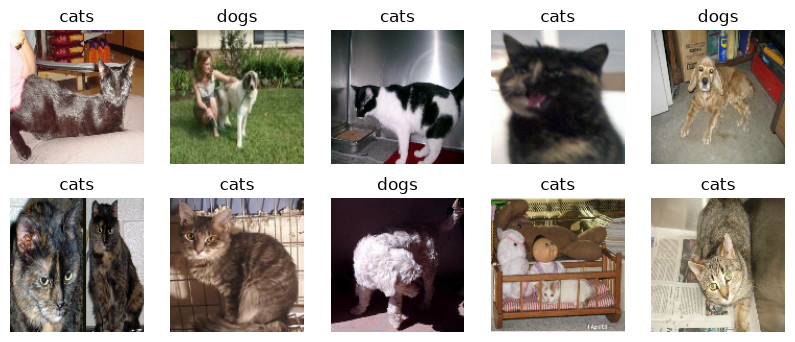

In [8]:
plt.figure(figsize=(10,4))
for image,label in train_data.take(1):
  for i in range(10):
    ax = plt.subplot(2,5,i+1)
    plt.imshow(image[i].numpy().astype('uint8'))
    plt.title(class_names[label[i]])
    plt.axis('off')

In [9]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal",input_shape=(128,128,3)),
        #tf.keras.layers.RandomRotation(0.2),
        #tf.keras.layers.RandomZoom(0.2),
        #tf.keras.layers.RandomZoom(
        #    height_factor=(-0.2, 0.2),
        #    width_factor=(-0.2, 0.2)
        #),
        tf.keras.layers.RandomZoom(
            height_factor=(-0.15, 0.50),
            fill_mode="constant",
            fill_value=255.0
        )
    ]
)

/opt/conda/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


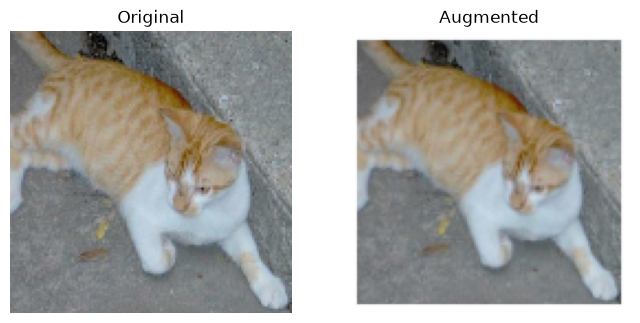

In [10]:
images, labels = next(iter(train_data))

image = images[0]

augmented_image = data_augmentation(
    tf.expand_dims(image, axis=0),
    training=True
)[0]

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(tf.cast(image, tf.uint8))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(tf.cast(augmented_image, tf.uint8))
plt.title("Augmented")
plt.axis("off")

plt.show()

In [11]:
for image,label in train_data.take(1):
  for i in range(1):
    print(image)

tf.Tensor(
[[[[ 38.55078     21.550781    31.550781  ]
   [ 39.90625     22.90625     32.90625   ]
   [ 36.6875      19.6875      29.6875    ]
   ...
   [  0.           1.           0.        ]
   [  0.           0.           0.        ]
   [  0.           0.           0.        ]]

  [[ 38.44922     21.449219    31.449219  ]
   [ 37.328125    20.328125    30.328125  ]
   [ 35.32422     18.324219    28.324219  ]
   ...
   [  0.           0.           0.        ]
   [  0.           0.32421875   0.        ]
   [  0.           0.           0.        ]]

  [[ 39.987534    22.987534    32.987534  ]
   [ 38.27568     21.27568     31.27568   ]
   [ 38.039062    21.039062    31.039062  ]
   ...
   [  1.           0.           0.        ]
   [  0.           1.           0.        ]
   [  0.           0.           0.        ]]

  ...

  [[184.55377    171.84134    185.32405   ]
   [191.96484    179.41348    193.68916   ]
   [197.16423    183.4764     196.32031   ]
   ...
   [ 12.           1.   

In [12]:
#transfer learning
pretrained_model = tf.keras.applications.xception.Xception(include_top=False,
                                                           input_shape=(128,128,3),
                                                           weights='imagenet',
                                                           pooling='max')
for layer in pretrained_model.layers:
  layer.trainable = False

In [13]:
MobileNetV3Small = tf.keras.applications.MobileNetV3Small(
    input_shape=(128, 128, 3),
    include_top=False,
    weights="imagenet"
)
#for layer in MobileNetV3Small.layers[:-20]:
#    layer.trainable = False
    
MobileNetV3Small.trainable = False
MobileNetV3Small.summary()

/opt/conda/lib/python3.12/site-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


Model: "MobileNetV3Small"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 64, 64,    │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 64, 64,    │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64,    │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 65, 65,    │          0 │ activation[0][0]  │
│ (ZeroPadding2D)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │        144 │ expanded_conv_de… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 32, 32,    │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │          0 │ re_lu[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │        136 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │          0 │ expanded_conv_sq… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │        144 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 1, 1, 16)  │          0 │ expanded_conv_sq… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 1, 1, 16)  │          0 │ add_12[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1, 1, 16)  │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 32, 32,    │          0 │ re_lu[0][0],      │
│ (Multiply)          │ 16)               │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 32, 32,    │        256 │ expanded_conv_sq

 Total params: 939,120 (3.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 939,120 (3.58 MB)

In [14]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        #tf.keras.layers.RandomRotation(0.2),
        #tf.keras.layers.RandomZoom(0.2),
        tf.keras.layers.RandomZoom(
            height_factor=(-0.15, 0.50),
            fill_mode="constant",
            fill_value=255.0
        )
    ]
)

In [15]:
callbacks = [
        tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        mode="min"
    )
]

In [16]:
inputs = tf.keras.Input(shape=(128, 128, 3))
x = data_augmentation(inputs)
x = MobileNetV3Small(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

#modelV2 = tf.keras.Sequential([
#    tf.keras.Input(shape=(128, 128, 3)),
    #data_augmentation,
#    MobileNetV3Small,
#    tf.keras.layers.GlobalAveragePooling2D(),
#    tf.keras.layers.Dropout(0.2),
#    tf.keras.layers.Dense(1, activation="sigmoid"),
#])

In [17]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 4, 4, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 939,697 (3.58 MB)

 Trainable params: 577 (2.25 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [18]:
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy']
             )

In [19]:
epochs = 100

In [20]:

start_time = time.time()

history_transfer  = model.fit(
    train_data,
    epochs=epochs,
    validation_data=validation_data,
    callbacks= callbacks
)
end_time = time.time()

Epoch 1/100


/opt/conda/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
E0000 00:00:1789575300.234294    1864 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


225/225 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.8294 - loss: 0.3710 - val_accuracy: 0.9275 - val_loss: 0.1972
Epoch 2/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9010 - loss: 0.2389 - val_accuracy: 0.9300 - val_loss: 0.1607
Epoch 3/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9083 - loss: 0.2144 - val_accuracy: 0.9337 - val_loss: 0.1501
Epoch 4/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9165 - loss: 0.2054 - val_accuracy: 0.9400 - val_loss: 0.1460
Epoch 5/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9199 - loss: 0.1937 - val_accuracy: 0.9425 - val_loss: 0.1404
Epoch 6/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9208 - loss: 0.1947 - val_accuracy: 0.9413 - val_loss: 0.1373
Epoch 7/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9235 - loss: 0.1900 - val_accuracy: 0.9450 - val_loss: 0.1358
Epoch 8/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9232 - loss: 0.1860 - val_accuracy: 0.9

In [21]:
history_transfer .history

{'accuracy': [0.8294444680213928,
  0.9009722471237183,
  0.9083333611488342,
  0.9165277481079102,
  0.9198611378669739,
  0.9208333492279053,
  0.9234722256660461,
  0.9231944680213928,
  0.9286110997200012,
  0.9270833134651184,
  0.9270833134651184,
  0.9241666793823242,
  0.9308333396911621,
  0.930138885974884,
  0.9272222518920898,
  0.9305555820465088,
  0.9286110997200012,
  0.9288889169692993,
  0.9302777647972107,
  0.9286110997200012,
  0.9284722208976746,
  0.9275000095367432,
  0.9273611307144165,
  0.9306944608688354,
  0.9284722208976746,
  0.9277777671813965,
  0.9318055510520935,
  0.9283333420753479,
  0.9263888597488403,
  0.9293055534362793,
  0.9304166436195374,
  0.9266666769981384,
  0.9288889169692993,
  0.9279166460037231,
  0.929444432258606,
  0.9302777647972107,
  0.9298611283302307,
  0.9291666746139526,
  0.9266666769981384,
  0.9293055534362793,
  0.9306944608688354],
 'loss': [0.3710450530052185,
  0.23889538645744324,
  0.21439537405967712,
  0.2053618

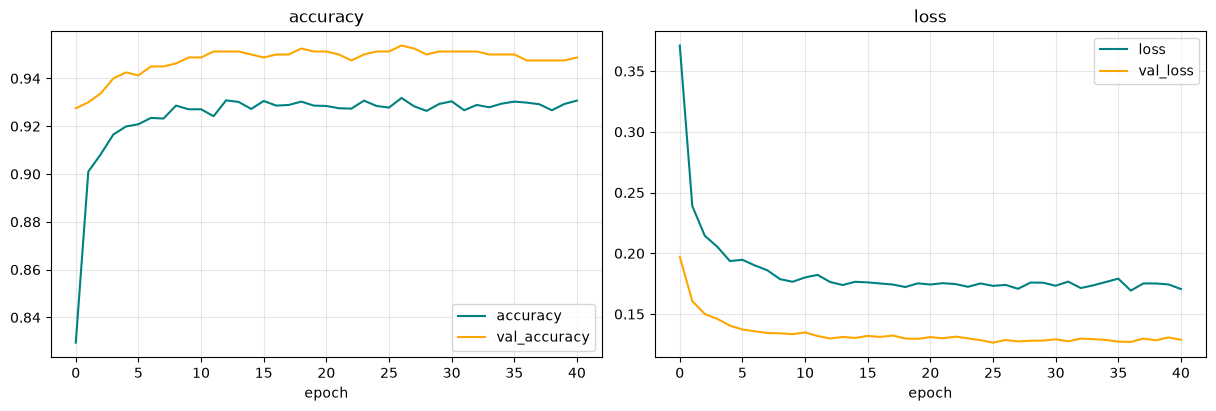

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
fig.get_layout_engine().set(w_pad=0.02, wspace=0.02)

axs[0].plot(history_transfer .history["accuracy"], color="teal", label="accuracy")
axs[0].plot(history_transfer .history["val_accuracy"], color="orange", label="val_accuracy")
axs[0].set_title("accuracy")

axs[1].plot(history_transfer .history["loss"], color="teal", label="loss")
axs[1].plot(history_transfer .history["val_loss"], color="orange", label="val_loss")
axs[1].set_title("loss")

for ax in axs:
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.3)
    ax.legend()

plt.show()

In [23]:
timeV = end_time - start_time
timeV = timeV/60
timeV

1.489818771680196

In [24]:
precision = tf.keras.metrics.Precision()
recall = tf.keras.metrics.Recall()
accuracy = tf.keras.metrics.BinaryAccuracy()

In [25]:
for batch in test_data.as_numpy_iterator():
  X, y = batch
  yhat = model.predict(X)
  precision.update_state(y, yhat)
  recall.update_state(y, yhat)
  accuracy.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━

E0000 00:00:1789575518.131133    1867 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


In [26]:
print(f"precision: {precision.result()}")
print(f"recall: {recall.result()}")
print(f"accuracy: {accuracy.result()}")

precision: 0.9441056847572327
recall: 0.9290000200271606
accuracy: 0.9369999766349792


In [27]:
os.makedirs("checkpoints", exist_ok=True)
model.save("checkpoints/stage2.keras")

In [28]:
#fine tunning
MobileNetV3Small.trainable = True

for layer in MobileNetV3Small.layers[:-20]:
    layer.trainable = False

for layer in MobileNetV3Small.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

fine_tune_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        mode="min"
    )
]

model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy']
             )

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 4, 4, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 940,853 (3.59 MB)

 Trainable params: 347,473 (1.33 MB)

 Non-trainable params: 592,224 (2.26 MB)

 Optimizer params: 1,156 (4.52 KB)

In [29]:

start_time = time.time()

history_finetune  = model.fit(
    train_data,
    epochs=50,
    validation_data=validation_data,
    callbacks=fine_tune_callbacks
)
end_time = time.time()

Epoch 1/50


E0000 00:00:1789575574.647708    1866 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


225/225 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9326 - loss: 0.1694 - val_accuracy: 0.9500 - val_loss: 0.1246
Epoch 2/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9337 - loss: 0.1583 - val_accuracy: 0.9500 - val_loss: 0.1234
Epoch 3/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9362 - loss: 0.1549 - val_accuracy: 0.9500 - val_loss: 0.1228
Epoch 4/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9417 - loss: 0.1513 - val_accuracy: 0.9513 - val_loss: 0.1223
Epoch 5/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9404 - loss: 0.1471 - val_accuracy: 0.9538 - val_loss: 0.1217
Epoch 6/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9410 - loss: 0.1452 - val_accuracy: 0.9538 - val_loss: 0.1212
Epoch 7/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9432 - loss: 0.1369 - val_accuracy: 0.9525 - val_loss: 0.1210
Epoch 8/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9456 - loss: 0.1377 - val_accuracy: 0.9538 - va

In [30]:
history_finetune .history

{'accuracy': [0.9326388835906982,
  0.9337499737739563,
  0.9362499713897705,
  0.9416666626930237,
  0.940416693687439,
  0.9409722089767456,
  0.9431944489479065,
  0.945555567741394,
  0.9461110830307007,
  0.9481944441795349,
  0.949305534362793,
  0.9508333206176758,
  0.95333331823349,
  0.9570833444595337,
  0.956250011920929,
  0.9518055319786072,
  0.9565277695655823,
  0.9576388597488403,
  0.9608333110809326,
  0.9593055844306946,
  0.9598610997200012,
  0.9611111283302307,
  0.9651389122009277,
  0.9622222185134888,
  0.9693055748939514,
  0.9691666960716248,
  0.9681944251060486],
 'loss': [0.16936369240283966,
  0.1583385318517685,
  0.15490137040615082,
  0.15126244723796844,
  0.14708071947097778,
  0.14524459838867188,
  0.13686524331569672,
  0.13767629861831665,
  0.1348453164100647,
  0.12720894813537598,
  0.12476383149623871,
  0.12618587911128998,
  0.11925174295902252,
  0.1163392961025238,
  0.11631331592798233,
  0.11503883451223373,
  0.11306188255548477,
  0

In [31]:
timeV = end_time - start_time
timeV = timeV/60
timeV

1.0232081810633342

In [32]:
precision = tf.keras.metrics.Precision()
recall = tf.keras.metrics.Recall()
accuracy = tf.keras.metrics.BinaryAccuracy()

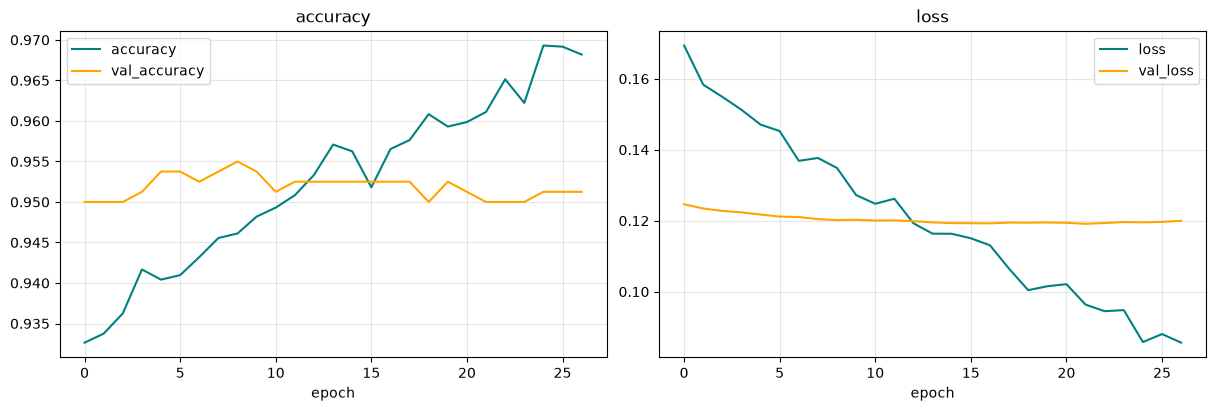

In [33]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
fig.get_layout_engine().set(w_pad=0.02, wspace=0.02)

axs[0].plot(history_finetune .history["accuracy"], color="teal", label="accuracy")
axs[0].plot(history_finetune .history["val_accuracy"], color="orange", label="val_accuracy")
axs[0].set_title("accuracy")

axs[1].plot(history_finetune .history["loss"], color="teal", label="loss")
axs[1].plot(history_finetune .history["val_loss"], color="orange", label="val_loss")
axs[1].set_title("loss")

for ax in axs:
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.3)
    ax.legend()

plt.show()

In [34]:
for batch in test_data.as_numpy_iterator():
  X, y = batch
  yhat = model.predict(X)
  precision.update_state(y, yhat)
  recall.update_state(y, yhat)
  accuracy.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━

In [35]:
print(f"precision: {precision.result()}")
print(f"recall: {recall.result()}")
print(f"accuracy: {accuracy.result()}")

precision: 0.9476334452629089
recall: 0.9409999847412109
accuracy: 0.9445000290870667


E0000 00:00:1789575742.617722    1863 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


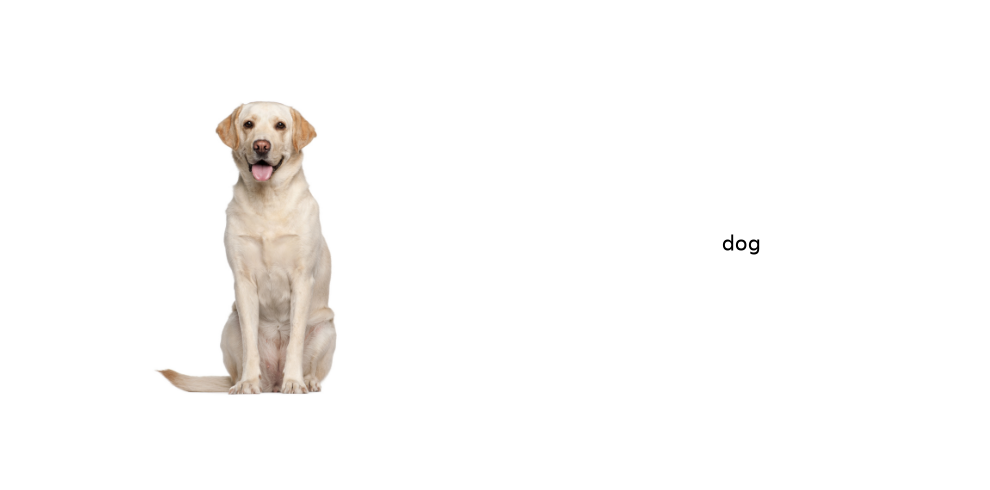

[[0.9920266]]


In [41]:
import keras
model = keras.saving.load_model("cat_dog_mobilenetv3DataAugmentation.keras")

image = cv2.imread("dog.png")
if image is None:
    raise FileNotFoundError("Could not read dog.png from the current working directory.")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

img = np.expand_dims(tf.image.resize(image, IMAGE_SIZE), 0)

y_hat = model.predict(img)

label = "dog" if y_hat > 0.5 else "cat"

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(image)
axs[0].axis('off')
axs[1].text(0.5, 0.5, label, fontsize=15, ha='center', va='center')
axs[1].axis('off')
plt.tight_layout()
plt.show()

print(y_hat)

In [36]:
model.save("cat_dog_mobilenetv3DataAugmentation.keras")

In [37]:
model.save_weights(
    "cat_dog_mobilenetv3DataAugmentation.weights.h5"
)

In [38]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_model = converter.convert()

with open("cat_dog_mobilenetv3DataAugmentation.tflite", "wb") as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: /tmp/tmpi7jrmd35/assets


INFO:tensorflow:Assets written to: /tmp/tmpi7jrmd35/assets


Saved artifact at '/tmp/tmpi7jrmd35'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_311')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  128794461201296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128794461201488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128794461202448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128794461202064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128794461202256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128796136606608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128794461201872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128794461202640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128794461195920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128794461203216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1287944612

W0000 00:00:1789575725.684973    1702 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1789575725.685004    1702 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


In [39]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]

tflite_optimized = converter.convert()

with open(
    "cat_dog_mobilenetv3DataAugmentation_optimized.tflite",
    "wb"
) as f:
    f.write(tflite_optimized)

INFO:tensorflow:Assets written to: /tmp/tmp6pxohrm2/assets


INFO:tensorflow:Assets written to: /tmp/tmp6pxohrm2/assets


Saved artifact at '/tmp/tmp6pxohrm2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_311')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  128794461201296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128794461201488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128794461202448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128794461202064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128794461202256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128796136606608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128794461201872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128794461202640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128794461195920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128794461203216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1287944612

W0000 00:00:1789575729.724027    1702 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1789575729.724066    1702 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


In [40]:
import os

print(
    "Normal:",
    os.path.getsize("cat_dog_mobilenetv3DataAugmentation.tflite") / 1024 / 1024,
    "MB"
)

print(
    "Optimizado:",
    os.path.getsize("cat_dog_mobilenetv3DataAugmentation_optimized.tflite") / 1024 / 1024,
    "MB"
)

Normal: 3.5802764892578125 MB
Optimizado: 1.078948974609375 MB
